# Cleaned Dataset Analysis - 90K Tracks

**Analysis of the cleaned, deduplicated dataset loaded into PostgreSQL**

This notebook analyzes:
- Data quality improvements (before/after cleaning)
- Genre distribution
- Audio feature statistics
- Popularity trends
- Recommendation algorithm validation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)

## 1. Load Cleaned Dataset

In [2]:
# Load cleaned dataset
df_clean = pd.read_csv('../Data/dataset_cleaned.csv')

print(f"✅ Loaded {len(df_clean):,} tracks")
print(f"✅ {df_clean.shape[1]} columns")

df_clean.head()

✅ Loaded 89,740 tracks
✅ 20 columns


,track_id,track_name,artists,album_name,track_genre,popularity,duration_ms,explicit,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,key,mode,time_signature
0,0fROT4kK5oTm8xO8PX6EJF,!I'll Be Back!,Rilès,!I'll Be Back!,french,52,178533,True,0.823,0.6120,0.2480,0.168,0.00000,0.1090,0.6880,142.959,-7.767,1,1,4.0
1,1hH0t381PIXmUVWyG1Vj3p,"""A"" You're Adorable",Brian Hyland,The Bashful Blond,rockabilly,39,151680,False,0.615,0.3750,0.0319,0.482,0.00000,0.1110,0.9220,110.720,-10.362,0,0,4.0
2,1B45DvGMoFWdbAEUH2qliG,"""C"" IS FOR COOKIE",Little Apple Band,The Favorite Songs Of Sesame Street,kids,32,84305,False,0.553,0.8120,0.0558,0.132,0.00001,0.0794,0.8710,118.368,-5.542,3,1,4.0
3,73lXf5if6MWVWnsgXhK8bd,"""C"" is for Cookie",Little Apple Band,Sesame Street and Friends,kids,8,86675,False,0.664,0.6110,0.0886,0.120,0.00000,0.0408,0.7580,118.443,-8.687,3,1,4.0
4,0jmz4aHEIBCRgrcV2xEkwB,"""Christe, Redemptor omnium""","Traditional, Sistine Chapel Choir, Massimo Pal...",Classical Christmas,sleep,0,289133,False,0.111,0.0568,0.0551,0.990,0.69700,0.1100,0.0395,169.401,-28.053,10,1,1.0


## 2. Compare: Original vs Cleaned Dataset

In [3]:
# Load original dataset for comparison
df_original = pd.read_csv('../Data/dataset.csv')

print("Dataset Comparison:")
print("=" * 60)
print(f"Original dataset:     {len(df_original):,} rows")
print(f"Cleaned dataset:      {len(df_clean):,} rows")
print(f"Removed duplicates:   {len(df_original) - len(df_clean):,} rows")
print(f"Reduction:            {(1 - len(df_clean)/len(df_original))*100:.1f}%")
print("\nData Quality:")
print("=" * 60)
print(f"Original missing values: {df_original.isnull().sum().sum():,}")
print(f"Cleaned missing values:  {df_clean.isnull().sum().sum():,}")

Dataset Comparison:
Original dataset:     114,000 rows
Cleaned dataset:      89,740 rows
Removed duplicates:   24,260 rows
Reduction:            21.3%

Data Quality:
Original missing values: 3
Cleaned missing values:  319


## 3. Audio Feature Distributions (Cleaned Data)

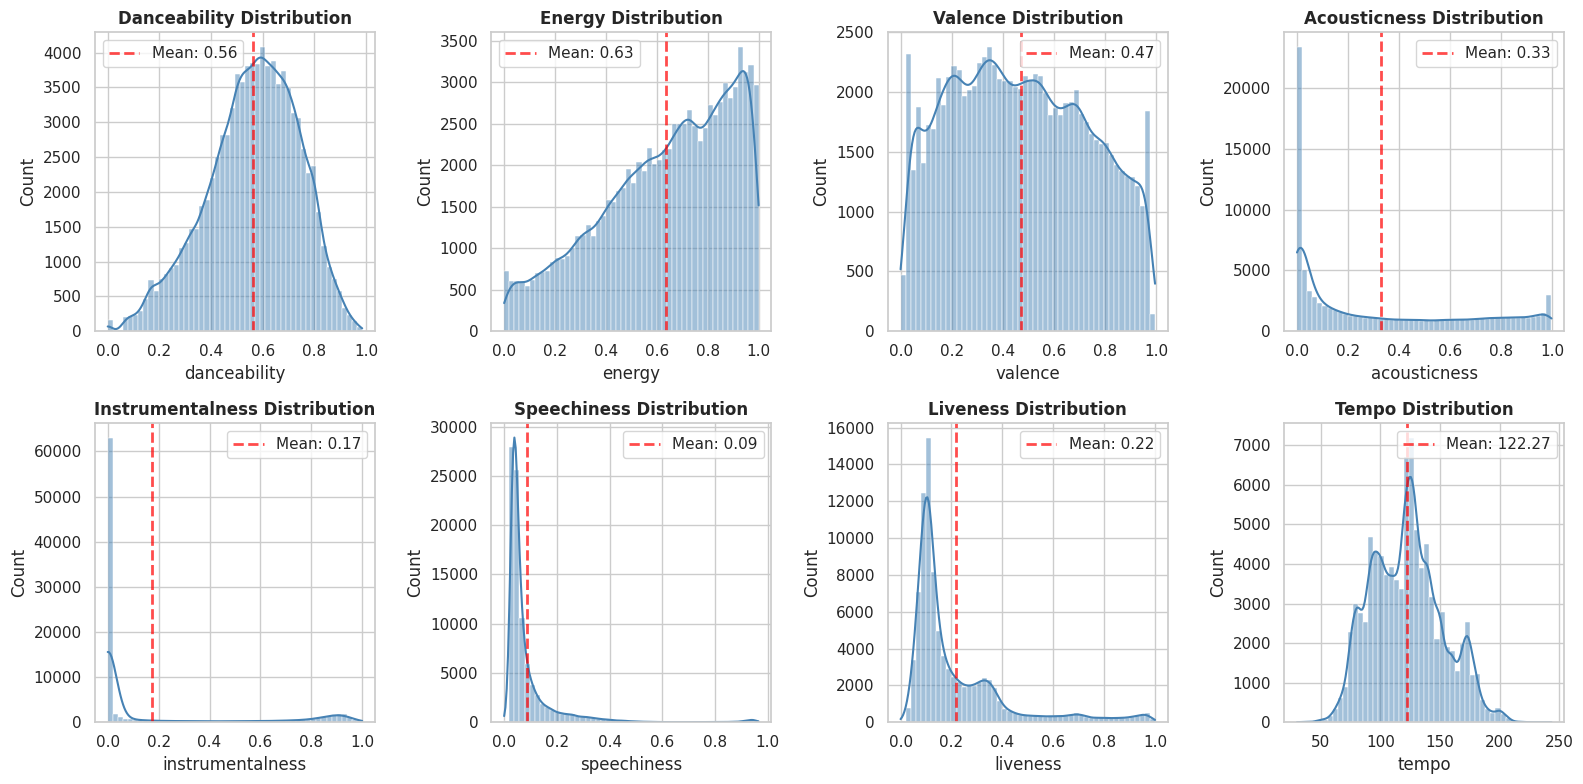


Audio Feature Statistics:
       danceability        energy       valence  acousticness  \
count  89740.000000  89740.000000  89740.000000  89740.000000   
mean       0.562166      0.634458      0.469474      0.328285   
std        0.176692      0.256606      0.262864      0.338321   
min        0.000000      0.000000      0.000000      0.000000   
25%        0.450000      0.457000      0.249000      0.017100   
50%        0.576000      0.676000      0.457000      0.188000   
75%        0.692000      0.853000      0.682000      0.625000   
max        0.985000      1.000000      0.995000      0.996000   

       instrumentalness   speechiness      liveness         tempo  
count      89740.000000  89740.000000  89740.000000  89583.000000  
mean           0.173415      0.087442      0.216971    122.272049  
std            0.323849      0.113278      0.194885     29.707011  
min            0.000000      0.000000      0.000000     30.200000  
25%            0.000000      0.036000      0.09

In [4]:
# Plot distributions for key audio features
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

features = ['danceability', 'energy', 'valence', 'acousticness', 
            'instrumentalness', 'speechiness', 'liveness', 'tempo']

for idx, feature in enumerate(features):
    sns.histplot(df_clean[feature], bins=50, kde=True, ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'{feature.capitalize()} Distribution', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(feature)
    
    # Add mean line
    mean_val = df_clean[feature].mean()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Mean: {mean_val:.2f}')
    axes[idx].legend()

plt.tight_layout()
plt.show()

print("\nAudio Feature Statistics:")
print(df_clean[features].describe())

## 4. Genre Analysis

Total unique genres: 113

Top 20 Genres:
track_genre
acoustic         1000
ambient           999
alt-rock          999
afrobeat          999
cantopop          999
tango             999
forro             998
disney            998
chicago-house     998
bluegrass         998
study             998
breakbeat         997
heavy-metal       997
sleep             997
black-metal       996
happy             995
anime             995
j-idol            995
club              994
idm               990
Name: count, dtype: int64


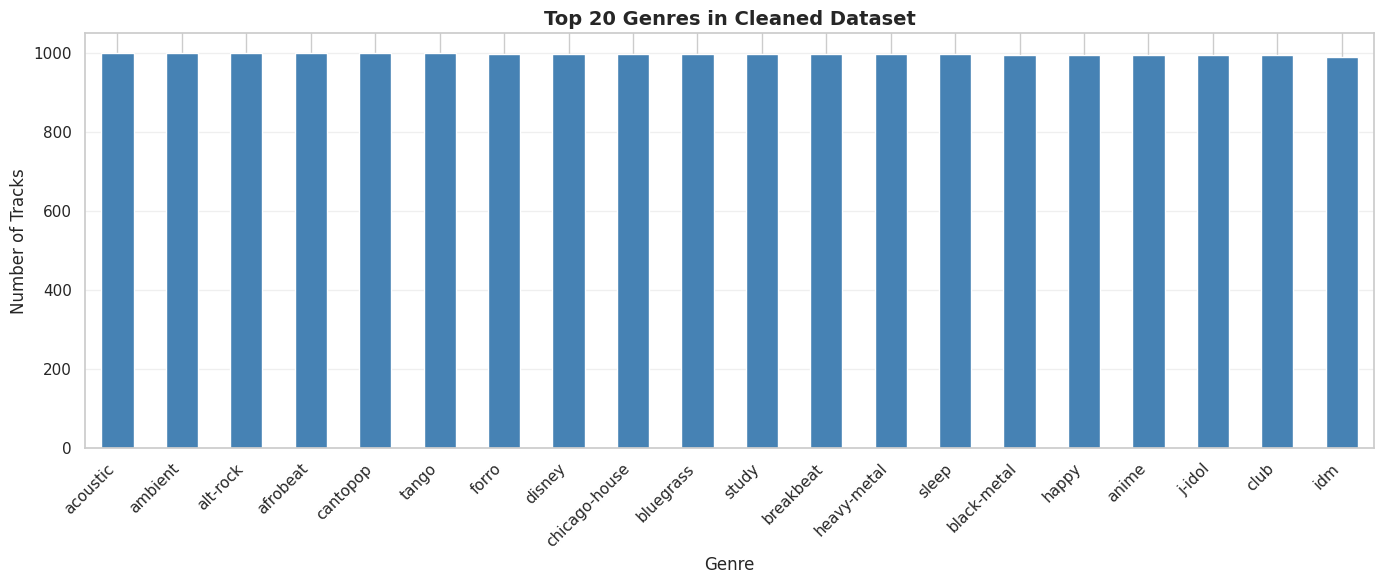

In [5]:
# Genre distribution
genre_counts = df_clean['track_genre'].value_counts()

print(f"Total unique genres: {len(genre_counts)}")
print(f"\nTop 20 Genres:")
print(genre_counts.head(20))

# Plot top 20 genres
plt.figure(figsize=(14, 6))
genre_counts.head(20).plot(kind='bar', color='steelblue')
plt.title('Top 20 Genres in Cleaned Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Number of Tracks')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Popularity Analysis

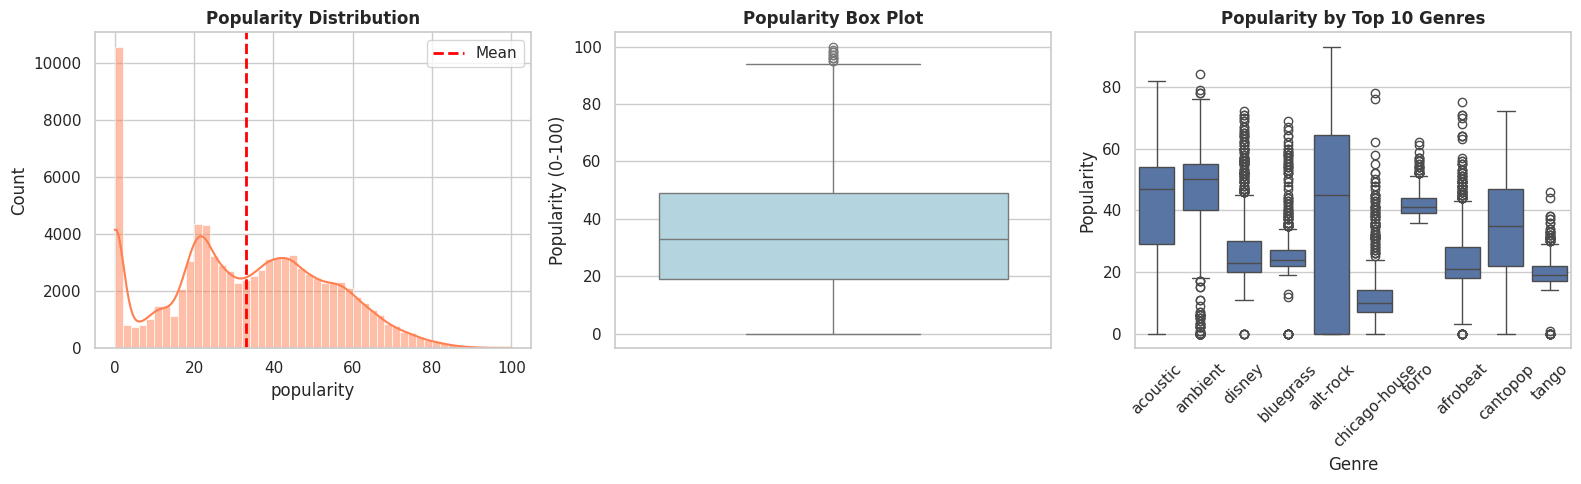

Mean popularity: 33.20
Median popularity: 33.00
Std deviation: 20.58


In [6]:
# Popularity distribution and stats
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram
sns.histplot(df_clean['popularity'], bins=50, kde=True, ax=axes[0], color='coral')
axes[0].set_title('Popularity Distribution', fontsize=12, fontweight='bold')
axes[0].axvline(df_clean['popularity'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0].legend()

# Boxplot
sns.boxplot(y=df_clean['popularity'], ax=axes[1], color='lightblue')
axes[1].set_title('Popularity Box Plot', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Popularity (0-100)')

# Popularity by genre (top 10 genres)
top_genres = genre_counts.head(10).index
df_top_genres = df_clean[df_clean['track_genre'].isin(top_genres)]
sns.boxplot(data=df_top_genres, x='track_genre', y='popularity', ax=axes[2])
axes[2].set_title('Popularity by Top 10 Genres', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Genre')
axes[2].set_ylabel('Popularity')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"Mean popularity: {df_clean['popularity'].mean():.2f}")
print(f"Median popularity: {df_clean['popularity'].median():.2f}")
print(f"Std deviation: {df_clean['popularity'].std():.2f}")

## 6. Feature Correlation Analysis

**Which features correlate with popularity?**

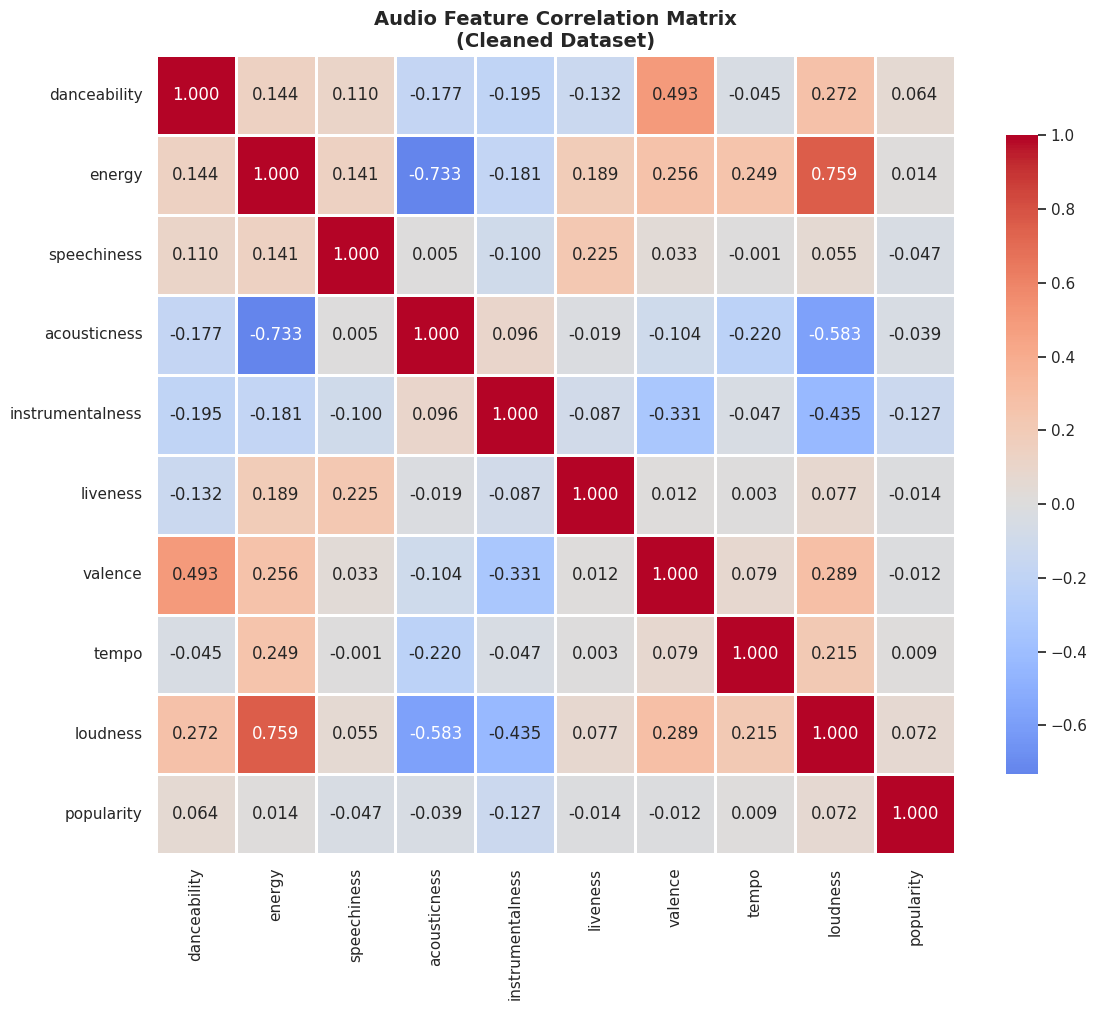


🎯 Features Most Correlated with Popularity:
popularity          1.000000
loudness            0.071674
danceability        0.064275
energy              0.013725
tempo               0.008790
valence            -0.011508
liveness           -0.013857
acousticness       -0.038828
speechiness        -0.047086
instrumentalness   -0.127477
Name: popularity, dtype: float64


In [7]:
# Correlation matrix
features_for_corr = ['danceability', 'energy', 'speechiness', 'acousticness',
                     'instrumentalness', 'liveness', 'valence', 'tempo', 'loudness', 'popularity']

corr_matrix = df_clean[features_for_corr].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Audio Feature Correlation Matrix\n(Cleaned Dataset)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Features most correlated with popularity
print("\n🎯 Features Most Correlated with Popularity:")
print("=" * 50)
pop_corr = corr_matrix['popularity'].sort_values(ascending=False)
print(pop_corr)

## 7. Artist Analysis

Total unique artists: 31,437

Top 20 Artists by Track Count:
artists
George Jones                       260
my little airport                  171
The Beatles                        149
BTS                                143
Håkan Hellström                    141
Glee Cast                          139
Hank Williams                      136
Linkin Park                        133
Scooter                            130
OneRepublic                        124
CoComelon                          122
Ella Fitzgerald                    111
Arctic Monkeys                     110
Dean Martin                        110
Charlie Brown Jr.                  106
Vybz Kartel                        106
Germaine Franco                    106
Elvis Presley                      105
The Beach Boys                     104
Hank Williams, Drifting Cowboys    104
Name: count, dtype: int64


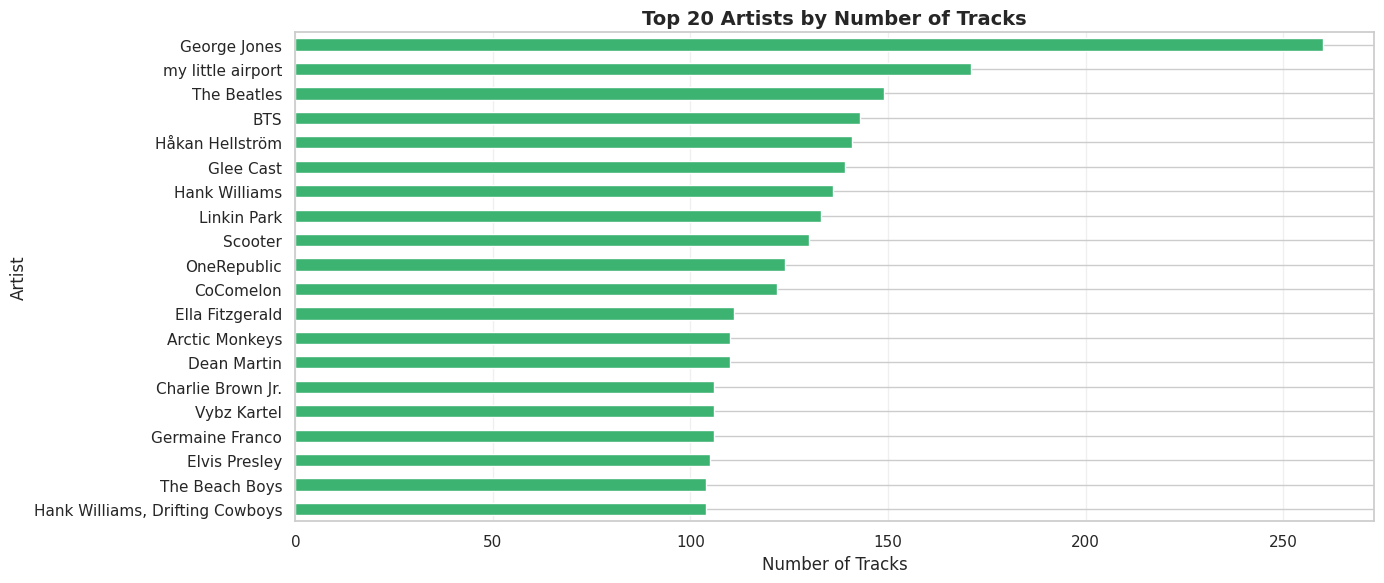

In [8]:
# Top artists by track count
artist_counts = df_clean['artists'].value_counts()

print(f"Total unique artists: {len(artist_counts):,}")
print(f"\nTop 20 Artists by Track Count:")
print(artist_counts.head(20))

# Plot
plt.figure(figsize=(14, 6))
artist_counts.head(20).plot(kind='barh', color='mediumseagreen')
plt.title('Top 20 Artists by Number of Tracks', fontsize=14, fontweight='bold')
plt.xlabel('Number of Tracks')
plt.ylabel('Artist')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Recommendation Algorithm Validation

**Test similarity calculation with sample tracks**

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

# Select a sample track
sample_track = df_clean.iloc[0]

print("Sample Track for Similarity Test:")
print("=" * 60)
print(f"Track: {sample_track['track_name']}")
print(f"Artist: {sample_track['artists']}")
print(f"Genre: {sample_track['track_genre']}")
print(f"Energy: {sample_track['energy']:.3f}, Valence: {sample_track['valence']:.3f}")

# Create feature vector
feature_cols = ['danceability', 'energy', 'speechiness', 'acousticness',
                'instrumentalness', 'liveness', 'valence']

# Calculate similarities
sample_features = sample_track[feature_cols].values.reshape(1, -1)
all_features = df_clean[feature_cols].values

similarities = cosine_similarity(sample_features, all_features)[0]
df_clean['similarity'] = similarities

# Get top 10 most similar (excluding itself)
similar_tracks = df_clean[df_clean['track_id'] != sample_track['track_id']].nlargest(10, 'similarity')

print("\n🎵 Top 10 Most Similar Tracks:")
print("=" * 60)
for idx, (_, track) in enumerate(similar_tracks.iterrows(), 1):
    print(f"{idx}. {track['track_name']} - {track['artists']}")
    print(f"   Genre: {track['track_genre']}, Similarity: {track['similarity']:.4f}")
    print(f"   Energy: {track['energy']:.3f}, Valence: {track['valence']:.3f}")
    print()

# Clean up
df_clean.drop('similarity', axis=1, inplace=True)

Sample Track for Similarity Test:
Track: !I'll Be Back!
Artist: Rilès
Genre: french
Energy: 0.612, Valence: 0.688

🎵 Top 10 Most Similar Tracks:
1. Can I Kick It? - A Tribe Called Quest
   Genre: hardcore, Similarity: 0.9996
   Energy: 0.666, Valence: 0.744

2. Dragonfruit - Lugatti & 9ine
   Genre: german, Similarity: 0.9996
   Energy: 0.628, Valence: 0.754

3. Détail - Captaine Roshi, Alpha Wann
   Genre: french, Similarity: 0.9995
   Energy: 0.632, Valence: 0.686

4. Crazy - Horace Andy
   Genre: dub, Similarity: 0.9995
   Energy: 0.547, Valence: 0.603

5. Relationship - Anthony Ramos
   Genre: show-tunes, Similarity: 0.9993
   Energy: 0.562, Valence: 0.618

6. Chase The Devil - Max Romeo, The Upsetters
   Genre: dub, Similarity: 0.9986
   Energy: 0.620, Valence: 0.744

7. Cold Rock a Party - MC Lyte
   Genre: hardcore, Similarity: 0.9986
   Energy: 0.744, Valence: 0.746

8. Have a Great Day - Jack Hartmann
   Genre: kids, Similarity: 0.9985
   Energy: 0.694, Valence: 0.792

9. Chas

## 9. Data Quality Summary

In [10]:
print("📊 CLEANED DATASET QUALITY REPORT")
print("=" * 60)
print(f"Total Tracks:           {len(df_clean):,}")
print(f"Unique Track IDs:       {df_clean['track_id'].nunique():,}")
print(f"Unique Artists:         {df_clean['artists'].nunique():,}")
print(f"Unique Genres:          {df_clean['track_genre'].nunique():,}")
print(f"\nMissing Values:         {df_clean.isnull().sum().sum():,}")
print(f"Duplicate Track IDs:    {df_clean['track_id'].duplicated().sum():,}")
print(f"\nAudio Features Coverage:")
for feat in feature_cols:
    coverage = (df_clean[feat].notna().sum() / len(df_clean)) * 100
    print(f"  {feat:20s}: {coverage:5.1f}%")
print("\n✅ Dataset is CLEAN and ready for recommendation engine!")

📊 CLEANED DATASET QUALITY REPORT
Total Tracks:           89,740
Unique Track IDs:       89,740
Unique Artists:         31,437
Unique Genres:          113

Missing Values:         319
Duplicate Track IDs:    0

Audio Features Coverage:
  danceability        : 100.0%
  energy              : 100.0%
  speechiness         : 100.0%
  acousticness        : 100.0%
  instrumentalness    : 100.0%
  liveness            : 100.0%
  valence             : 100.0%

✅ Dataset is CLEAN and ready for recommendation engine!


## 10. Export Sample for Testing

In [11]:
# Export a small sample for quick testing
sample_size = 1000
df_sample = df_clean.sample(n=sample_size, random_state=42)
df_sample.to_csv('../Data/dataset_sample_1k.csv', index=False)

print(f"✅ Exported {sample_size:,} random tracks to dataset_sample_1k.csv")
print("   Use this for quick testing!")

✅ Exported 1,000 random tracks to dataset_sample_1k.csv
   Use this for quick testing!
